In [1]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Piccolo
using LinearAlgebra
using Printf
using CairoMakie

## Operators and Hamiltonian

Same as `03_andrew (2).ipynb`, but with `time_dependent=true` so the NLP integrator uses the actual rotating-frame modulation `cos(δ₁₂t)` / `sin(δ₁₂t)` at each knot.

In [3]:
δ12 = 2π * 0.05

XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
IX = operator_from_string("IX")
YI = operator_from_string("YI")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

bounds = fill(2π * 0.01, 5)

function H(u, t)
    g, uX1, uY1, uX2, uY2 = u
    return (
        δ12/2 * IZ
        + g * ((XX + YY) * cos(δ12 * t) + (YX - XY) * sin(δ12 * t))
        + uX1 * XI + uY1 * YI
        + uX2 * IX + uY2 * IY
    )
end

U_goal = exp(-im * π / 4 * (XX + YY))

# time_dependent=true: BilinearIntegrator will evaluate G(u_k, t_k) at each knot
sys = QuantumSystem(H, bounds; time_dependent=true)
println(sys)

QuantumSystem: levels = 4, n_drives = 5


## Initial pulse and trajectory

Same random initialization as `03_andrew`: 300 uniformly sampled knots.

In [12]:
function sample_uniform(bounds::AbstractVector{Tuple{Float64,Float64}}, n::Int)
    return [(high - low) * rand() + low for (low, high) in bounds, _ in 1:n]
end

n_samples = 300
T = 100.0
N = 20
Δt = T / N

controls = sample_uniform(sys.drive_bounds, n_samples)
times    = collect(LinRange(0.0, T, n_samples))
pulse    = LinearSplinePulse(controls, times)

qtraj = UnitaryTrajectory(sys, pulse, U_goal)
qcp   = SplinePulseProblem(qtraj, N; Δt_bounds=(0.5Δt, 2Δt))

    constructing SplinePulseProblem with LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}...
	applying timesteps_all_equal constraint: Δt
    added DerivativeIntegrator for LinearSplinePulse


QuantumControlProblem{UnitaryTrajectory{LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}, SciMLBase.ODESolution{ComplexF64, 3, Vector{Matrix{ComplexF64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Matrix{ComplexF64}}}, Nothing, SciMLBase.ODEProblem{Matrix{ComplexF64}, Tuple{Float64, Float64}, true, SciMLBase.NullParameters, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, SciMLOperators.MatrixOperator{ComplexF64, Matrix{ComplexF64}, SciMLOperators.FilterKwargs{Nothing, Val{()}}, SciMLOperators.FilterKwargs{Piccolo.Quantum.Rollouts.var"#update!#6"{QuantumSystem{Piccolo.Quantum.QuantumSystems.var"#24#27"{typeof(H)}, Piccolo.Quantum.QuantumSystems.var"#25#28"{typeof(H)}, @NamedTuple{}, Vector{DriftTerm{SparseArrays.SparseMatrixCSC{ComplexF64, Int64}, Returns{Float64}, Returns{Float64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}, Val{()}}}, UniformScaling{Bool}, Nothing, Nothi

## Fix initial point: NLP-consistent re-initialization

`UnitaryTrajectory` initializes Ũ⃗ by integrating the original 300-knot pulse with MagnusAdapt4,
then sampling at N=100 NLP knot times. But the NLP equality constraints use
`TimeDependentBilinearIntegrator` (Tsit5) with only the 100 NLP knot control values linearly
interpolated between them. Within each 1 ns step the original pulse has ~3 knots — discarding
that detail causes inf_pr ≈ 1.76 at iter 0.

Fix: rebuild Ũ⃗ by integrating a `LinearSplinePulse` built from the NLP knot controls only,
so the initial point is consistent with what the NLP constraints expect.

In [13]:
let
    traj = get_trajectory(qcp)
    us   = traj[:u]       # (5, N) — NLP knot controls
    ts   = vec(traj[:t])  # (N,)   — NLP knot times

    # Build a new pulse using only the N NLP knot control values.
    # This matches what the NLP constraint (TimeDependentBilinearIntegrator) sees:
    # piecewise-linear interpolation between consecutive NLP knots.
    nlp_pulse  = LinearSplinePulse(us, ts)
    nlp_qtraj  = UnitaryTrajectory(sys, nlp_pulse, U_goal)

    # Sample Ũ⃗ at each NLP knot time from this consistent rollout
    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    # Write back into the NLP trajectory data
    rows = traj.components[:Ũ⃗]
    traj.data[rows, :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / sys.levels^2
    @printf("Initial fidelity (NLP-consistent init): %.4f\n", F0)
    @printf("(inf_pr should now be ~1e-8 at iter 0, not ~1.76)\n")
end

Initial fidelity (NLP-consistent init): 0.0418
(inf_pr should now be ~1e-8 at iter 0, not ~1.76)


## Solve

**Note on performance**: `TimeDependentBilinearIntegrator` runs a Tsit5 ODE solve + ForwardDiff
Jacobian for every NLP step on every evaluation (~99 ODE solves per constraint eval). This is
~10-20× slower than the frozen-t=0 case. Each iteration takes ~2s vs ~0.15s. Budget accordingly.

In [14]:
log_path = joinpath(pwd(), "ipopt_timedep.log")
rm(log_path; force=true)

solve!(qcp;
    max_iter = 100,
    options  = IpoptOptions(eval_hessian=false, output_file=log_path),
)

if isfile(log_path)
    lines = readlines(log_path)
    print(join(lines[max(1, end-30):end], "\n"))
end

    initializing optimizer...
      building evaluator: 2 integrators, 0 nonlinear constraints
      dynamics constraints: 703, nonlinear constraints: 0
        integrator 1 jacobian structure: 0.229s
        integrator 2 jacobian structure: 0.0s
      jacobian structure: 61864 nonzeros (0.229s)
        integrator 1 hessian structure: 0.001s
        integrator 2 hessian structure: 0.002s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.0s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (NullObjective): 0.0s
        objective hessian structure: 0.001s
      hessian structure: 56584 nonzeros (0.005s)
      linear index maps built (0.008s)
      evaluator ready (total: 0.243s)
    evaluator created (0.243s)
    NL constraint bounds extracted (0.0s)
    NLP block data built (0.0s)
    Ipopt optimizer configured (0.0s)
    variables s

## NLP fidelity

In [15]:
traj = get_trajectory(qcp)

# NLP fidelity: Ũ⃗[:,end] as stored in the NLP trajectory.
# Meaningful ONLY if inf_pr < ~1e-4. Otherwise Ipopt may have pushed
# Ũ⃗[:,end] toward U_goal without the dynamics being feasible.
U_nlp = iso_vec_to_operator(traj[:Ũ⃗][:, end])
F_nlp = abs2(tr(U_goal' * U_nlp)) / sys.levels^2

# Rollout fidelity: re-integrate traj[:u] from scratch — always honest.
F_rollout = unitary_rollout_fidelity(traj, sys)

@printf("NLP fidelity (Ũ⃗ end):  %.6f  (trust only if inf_pr < 1e-4)\n", F_nlp)
@printf("Rollout fidelity:        %.6f  (always honest)\n", F_rollout)

NLP fidelity (Ũ⃗ end):  0.999997  (trust only if inf_pr < 1e-4)
Rollout fidelity:        0.999975  (always honest)


## Rollout fidelity (true time-dependent dynamics)

Evaluate with the accurate ODE to see what the actual pulse achieves.

In [16]:
F_rollout = unitary_rollout_fidelity(traj, sys)
@printf("Rollout fidelity (no perturbation): %.6f\n", F_rollout)

Rollout fidelity (no perturbation): 0.999975


## Optimized controls

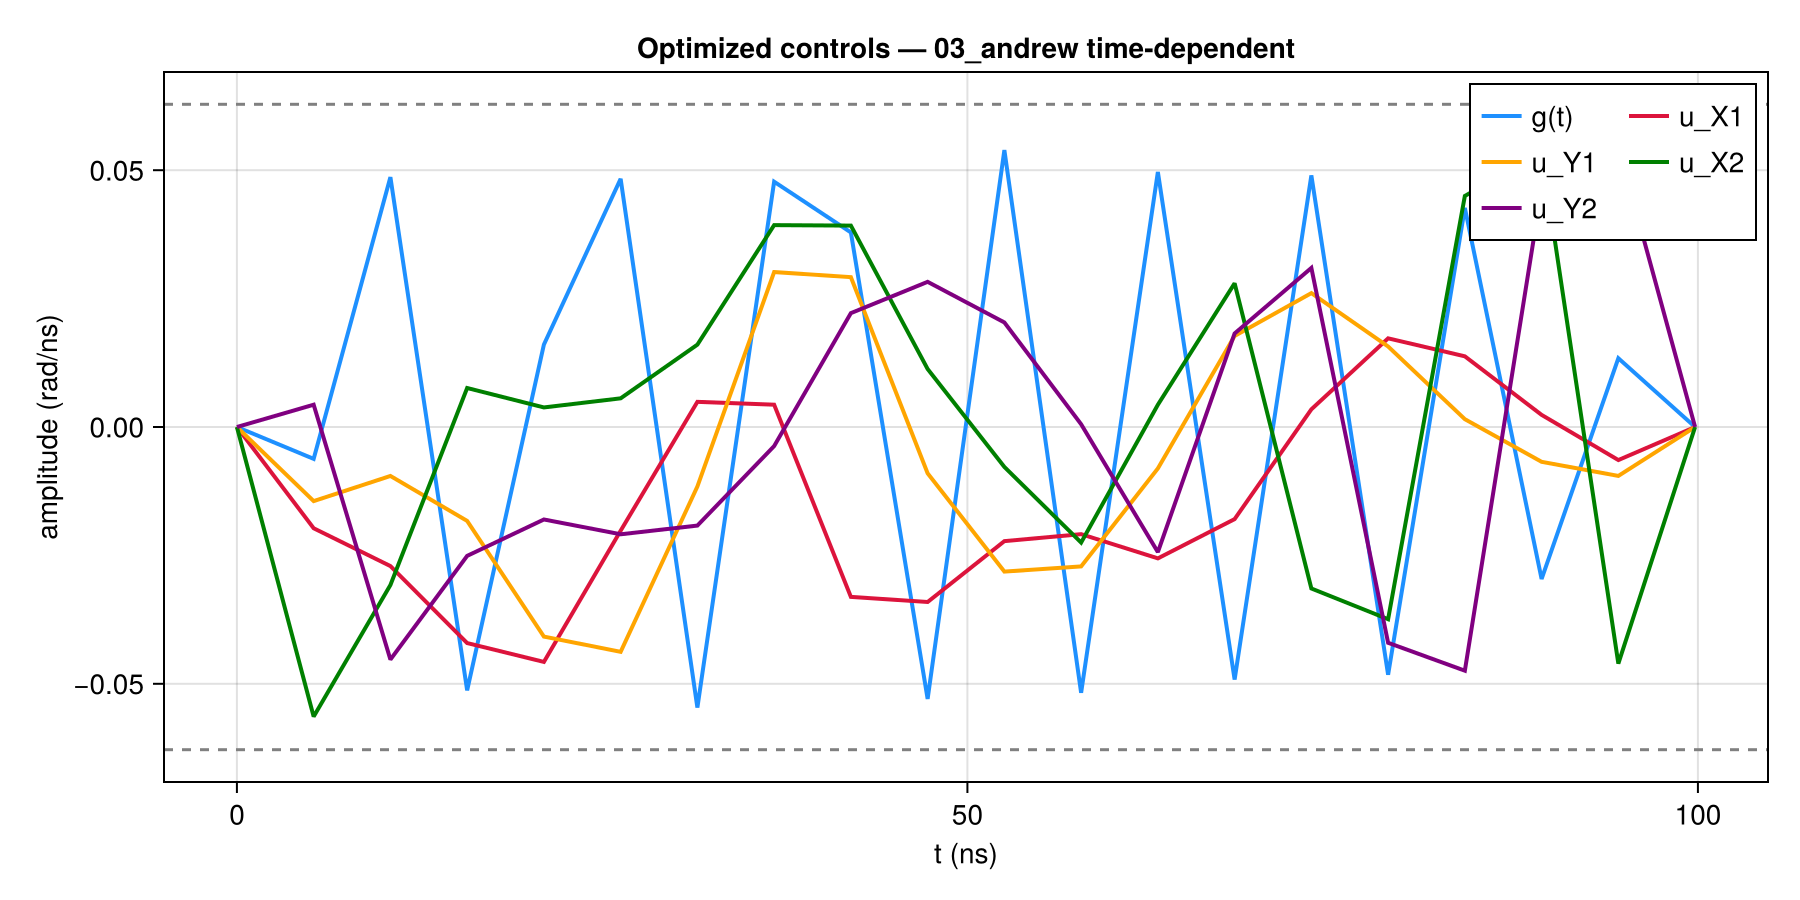

In [17]:
u   = traj[:u]
Δts = vec(traj[:Δt])
ts  = cumsum([0.0; Δts[1:end-1]])

fig = Figure(size=(900, 450))
ax  = Axis(fig[1,1];
    xlabel="t (ns)", ylabel="amplitude (rad/ns)",
    title="Optimized controls — 03_andrew time-dependent",
)
labels = ["g(t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
cols   = [:dodgerblue, :crimson, :orange, :green, :purple]
for (i, (lbl, col)) in enumerate(zip(labels, cols))
    lines!(ax, ts, vec(u[i,:]); label=lbl, color=col, linewidth=2)
end
hlines!(ax, [bounds[1], -bounds[1]]; linestyle=:dash, color=:gray)
axislegend(ax; position=:rt, nbanks=2)
fig

## Fidelity vs. coherent error strength ε

For each dephasing channel E ∈ {ZI, IZ, ZZ}, simulate the optimized pulse under
H(u,t) + ε·E using `unitary_rollout_fidelity` (MagnusAdapt4).  ε=0 should give the
same fidelity for all three channels (same Hamiltonian).

In [10]:
error_channels = [ZI, IZ, ZZ]
error_labels   = ["ZI", "IZ", "ZZ"]
εs = collect(range(-0.05, 0.05, length=51))

function make_perturbed_sys(ε, E)
    H_p = (u, t) -> H(u, t) + ε * E
    return QuantumSystem(H_p, bounds; time_dependent=true)
end

fidelities = [
    [unitary_rollout_fidelity(traj, make_perturbed_sys(ε, E)) for ε in εs]
    for E in error_channels
]

@printf("ε=0  ZI=%.5f  IZ=%.5f  ZZ=%.5f\n",
    fidelities[1][26], fidelities[2][26], fidelities[3][26])

ε=0  ZI=0.99996  IZ=0.99996  ZZ=0.99996


## Plots

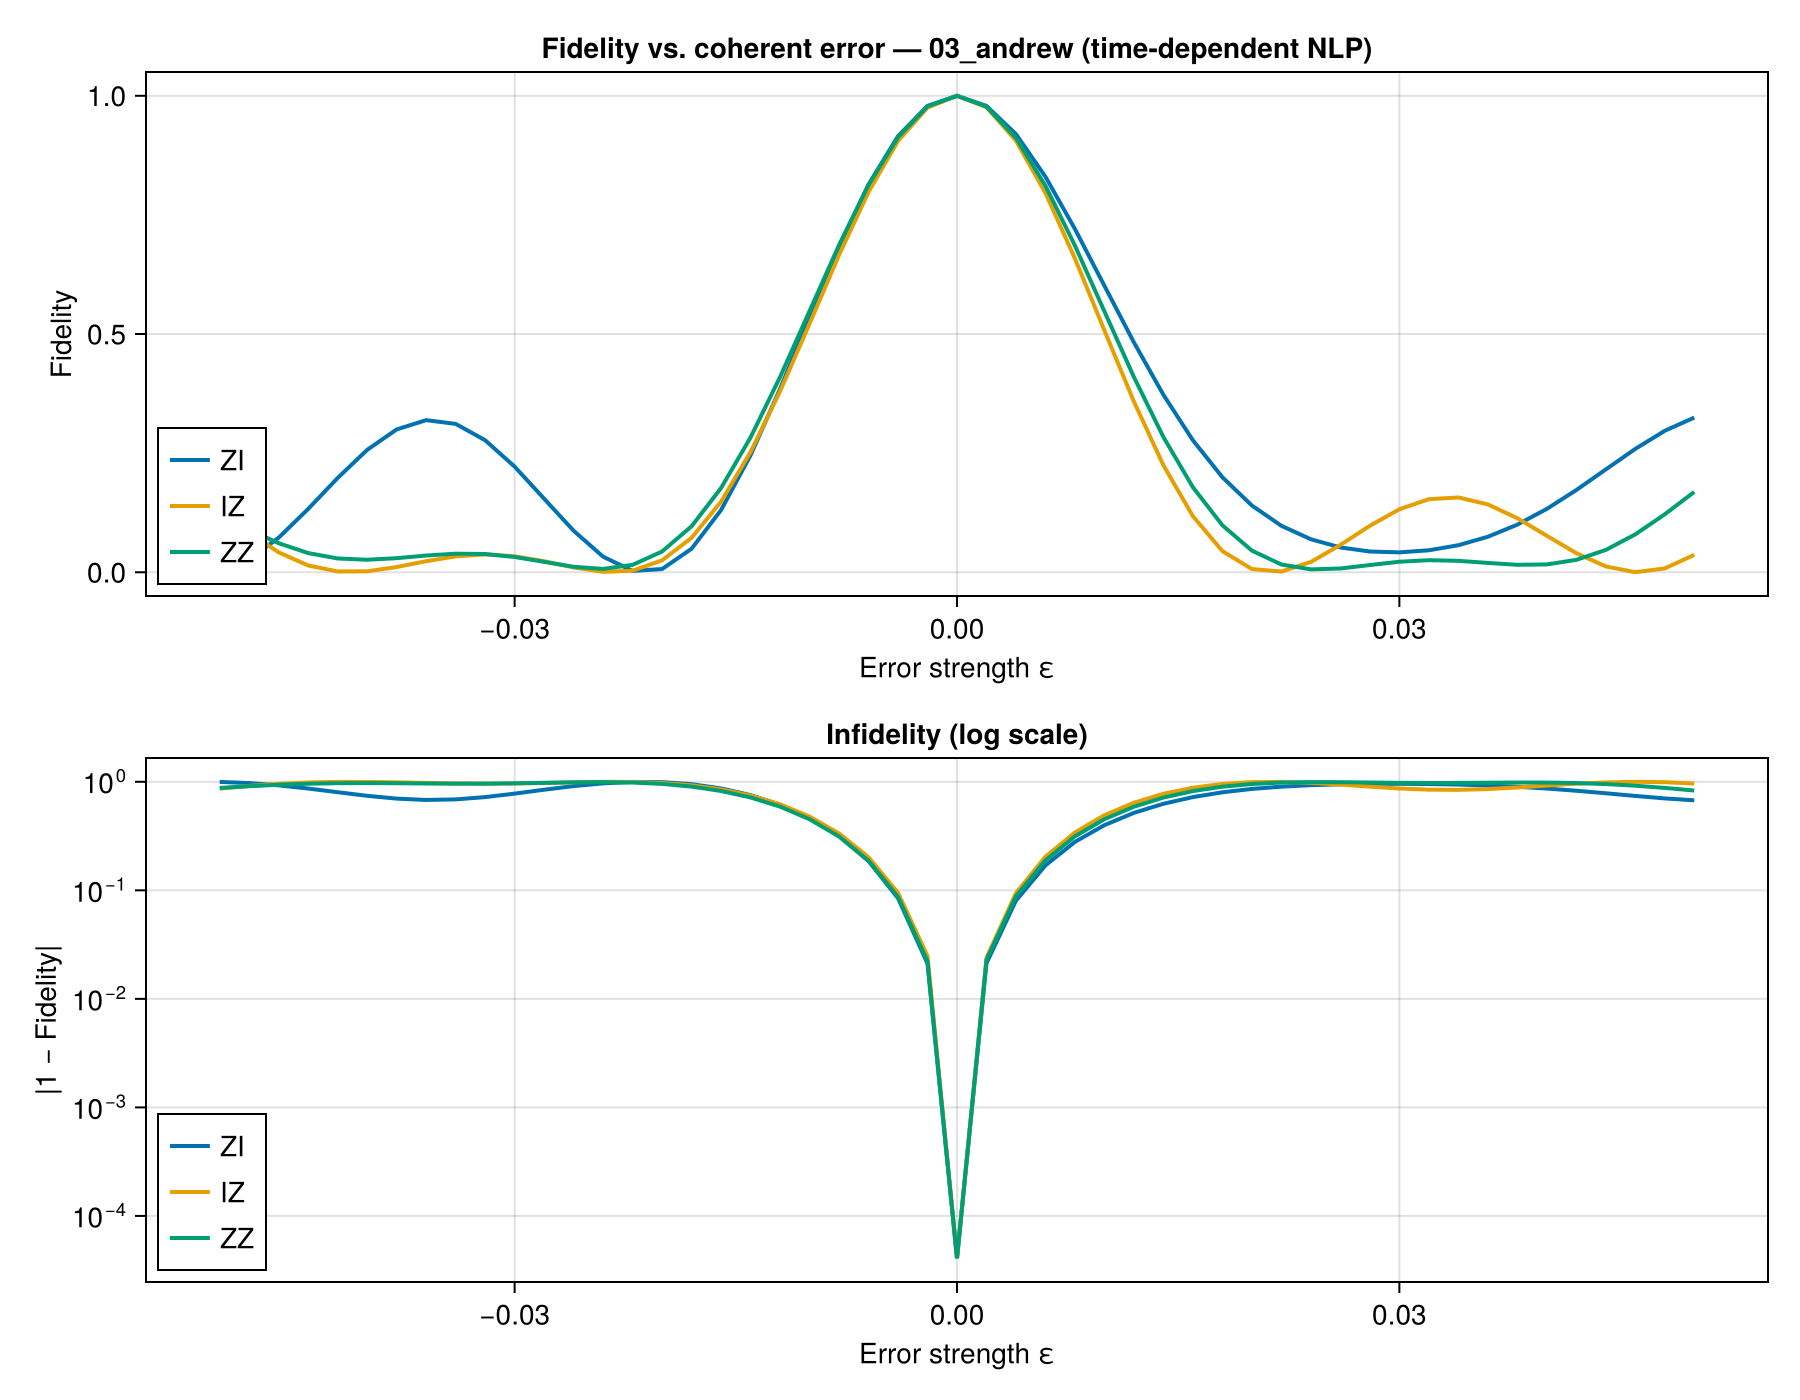

In [11]:
wong = Makie.wong_colors()

fig = Figure(size=(900, 700))

ax1 = Axis(fig[1,1];
    xlabel="Error strength ε",
    ylabel="Fidelity",
    title="Fidelity vs. coherent error — 03_andrew (time-dependent NLP)",
)
for (i, (lbl, fs)) in enumerate(zip(error_labels, fidelities))
    lines!(ax1, εs, fs; label=lbl, color=wong[i], linewidth=2)
end
axislegend(ax1; position=:lb)

ax2 = Axis(fig[2,1];
    xlabel="Error strength ε",
    ylabel="|1 − Fidelity|",
    title="Infidelity (log scale)",
    yscale=log10,
)
for (i, (lbl, fs)) in enumerate(zip(error_labels, fidelities))
    lines!(ax2, εs, max.(1 .- fs, 1e-16); label=lbl, color=wong[i], linewidth=2)
end
axislegend(ax2; position=:lb)

fig